### **Population Regression**

## The population regression of Singapore

Here are the libraries or functions in the libraries that we need to use

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import sklearn.linear_model as lm
import seaborn as sns
from matplotlib.pyplot import figure
import graphviz
%matplotlib inline

from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.metrics import mean_squared_error,r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso,LassoCV
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestRegressor
seed=123

# Use a Linear Regression model to make predictions

Then we read in the file

In [ ]:
df = pd.read_excel('Singapore.xlsx')

We then assign time and population values to x and y respectively to make the code more concise and easier to understand

In [ ]:
x=df["Year"]
y=df["Populations"]

Below is a graph of the change in Singapore's total population from 1950 to 2022

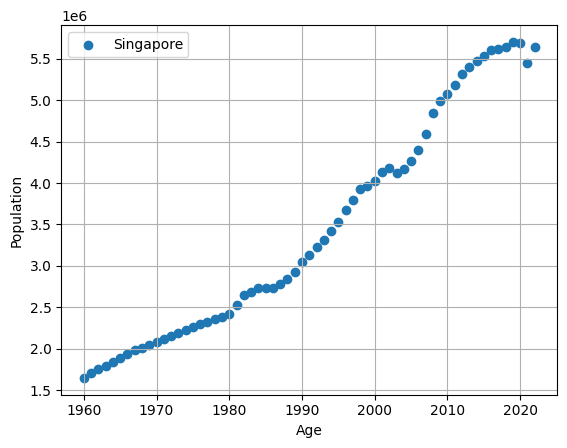

In [ ]:
plt.xlabel("Age")
plt.ylabel("Population")
plt.scatter(x,y,label="Singapore")
plt.legend()
plt.grid()

Next, we will use the simplest linear regression to make a population prediction for Singapore

Model Coefficients [slope, intercept]: [ 7.17744159e+04 -1.39440788e+08]


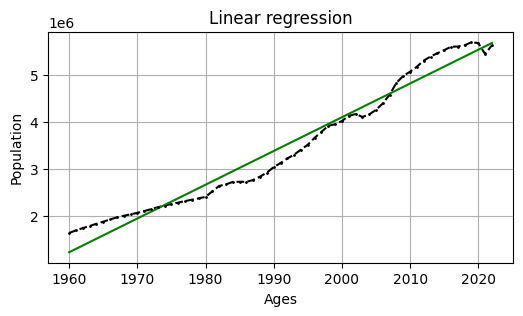

In [ ]:
# We are going to use LinearRegression.
lr = lm.LinearRegression()

# Next, we reshape x so that it satisfies the conditions for the fitting function
x=np.array(x).reshape(-1,1)

# Now we use data from 1960 to 2019 to train the model
lr.fit(x[:60],y[:60])

# Now, we predict points with our trained model.
y_lr = lr.predict(x)

#
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(x, y, '--k')
ax.plot(x, y_lr, 'g')
ax.plot(x, y, 'ok', ms=1)
#ax.set_xlim(0, 1.5)
#ax.set_ylim(-10, 80)
ax.set_title("Linear regression")
plt.xlabel("Ages")
plt.ylabel("Population")
plt.grid()
print('Model Coefficients [slope, intercept]:', np.append(lr.coef_, lr.intercept_))

Next, we will predict the error and the outcome

In [ ]:
print('The difference between the projected population and the actual population in 2020 is : ',int(lr.predict([[2020]])-y[60]),'\n')
print('The difference between the projected population and the actual population in 2021 is : ',int(lr.predict([[2021]])-y[61]),'\n')
print('The difference between the projected population and the actual population in 2022 is : ',int(lr.predict([[2022]])-y[62]),'\n')
print('The projected population of Singapore in 2023 is : ',int(lr.predict([[2023]])),'\n')
print('The projected population of Singapore in 2030 is : ',int(lr.predict([[2030]])),'\n')
print('The projected population of Singapore in 2050 is : ',int(lr.predict([[2050]])),'\n')


The difference between the projected population and the actual population in 2020 is :  -142274 

The difference between the projected population and the actual population in 2021 is :  161740 

The difference between the projected population and the actual population in 2022 is :  50058 

The projected population of Singapore in 2023 is :  5758855 

The projected population of Singapore in 2030 is :  6261276 

The projected population of Singapore in 2050 is :  7696764 



Next, we will use the function to get information about this regression line, before we first take a backup of x and then process x

In [ ]:
#add one conlumn
x_copy=x.copy()
x=sm.add_constant(x)

#ordinary least squares
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Populations   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     1705.
Date:                Thu, 03 Aug 2023   Prob (F-statistic):           2.72e-46
Time:                        15:02:50   Log-Likelihood:                -871.55
No. Observations:                  63   AIC:                             1747.
Df Residuals:                      61   BIC:                             1751.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.392e+08   3.46e+06    -40.287      0.0

From the table above, we can find that the R-squared coefficient of the regression line is 0.965

In [ ]:
cormatrix=df.corr()
cormatrix

,Year,Populations
Year,1.000000,0.982576
Populations,0.982576,1.000000


From the above table, we can see that the correlation coefficient of population to year is very close to 1, indicating that we can fit with straight lines

Next, we will calculate the MSE of the training data and the test data

In [ ]:
# First, we need to change the form of y so that it conforms to the form of the MSE
y_array = np.zeros(63)
for m in range(0,63):
  y_array[m] = y[m]

print('The MSE of the traning data is : ',mean_squared_error(y_array[:60],y_lr[:60]))
print('The MSE of the test data is : ',mean_squared_error(y_array[60:63],y_lr[60:63]))

The MSE of the traning data is :  62992491585.68098
The MSE of the test data is :  16302674820.726755


# Use a Polynomial Regression model to make predictions

Coefficients, degree 1:
	 71774.42 -139440788.05
[ 7.17744159e+04 -1.39440788e+08]
The MSE of the traning data is :  62992491585.68098
The MSE of the test data is :  16302674820.726755
Coefficients, degree 2:
	 865.23 -3370983.57 3284983221.63
[ 8.65231964e+02 -3.37098357e+06  3.28498322e+09]
The MSE of the traning data is :  9166240217.209423
The MSE of the test data is :  412511624369.8309
Coefficients, degree 3:
	 -4.83 29695.92 -60727025.89 41318141182.58
[-4.83047426e+00  2.96959176e+04 -6.07270259e+07  4.13181412e+10]
The MSE of the traning data is :  8778948286.281416
The MSE of the test data is :  328906993208.2691
Coefficients, degree 4:
	 -0.00 10.67 -16323.83 -12.31 11269439741.47
[-1.95730988e-03  1.06683529e+01 -1.63238286e+04 -1.23081544e+01
  1.12694397e+10]
The MSE of the traning data is :  8765685830.370506
The MSE of the test data is :  326991123181.9151


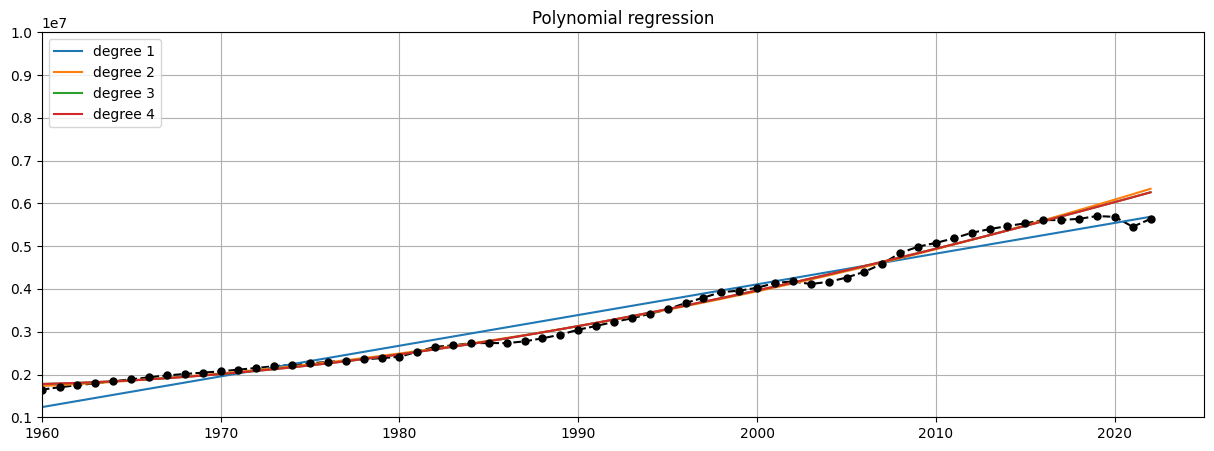

In [ ]:
lrp = lm.LinearRegression()
fig, ax = plt.subplots(1, 1,  figsize=(15, 5))
# Next we will change the two-dimensional array to a one-dimensional array to meet the request
x_flatten = x_copy.flatten()
ax.plot(x_copy, y, '--k')
for deg, s in zip([1, 2, 3, 4], ['-','-', '-','-']):
    lrp.fit(np.vander(x_flatten[:60], deg + 1), y[:60])
    y_lrp = lrp.predict(np.vander(x_flatten, deg + 1))
    ax.plot(x_copy, y_lrp, s, label='degree ' + str(deg))
    ax.legend(loc=2)
    ax.set_xlim(1960, 2025)
    ax.set_ylim(1000000, 10000000)
    # Print the model's coefficients.
    coeff=np.append(lrp.coef_[:-1],lrp.intercept_)
    print(f'Coefficients, degree {deg}:\n\t',' '.join(f'{c:.2f}' for c in coeff ))
    print(coeff)
    print('The MSE of the traning data is : ',mean_squared_error(y_array[:60],y_lrp[:60]))
    print('The MSE of the test data is : ',mean_squared_error(y_array[60:63],y_lrp[60:63]))
ax.plot(x_copy, y, 'ok', ms=5)
ax.set_title("Polynomial regression")
ax.grid()

# Use a Ridge regression model to make predictions

Coefficients, degree 1:
	 71734.55 -139361479.41
[ 7.17345523e+04 -1.39361479e+08]
The MSE of the traning data is :  62992968185.29094
The MSE of the test data is :  16240940030.95536
Coefficients, degree 2:
	 637.78 -2465959.47 2384805645.46
[ 6.37775024e+02 -2.46595947e+06  2.38480565e+09]
The MSE of the traning data is :  12886326930.368038
The MSE of the test data is :  237504778025.0096
Coefficients, degree 3:
	 -32.00 -826.69 -4289.57 255330683847.41
[-3.20000000e+01 -8.26691162e+02 -4.28956738e+03  2.55330684e+11]
The MSE of the traning data is :  4.408019301403263e+19
The MSE of the test data is :  1.4916995499783753e+20
Coefficients, degree 4:
	 776.00 10.06 -14983.66 -10.65 -12162857354462456.00
[ 7.76000000e+02  1.00644531e+01 -1.49836595e+04 -1.06481169e+01
 -1.21628574e+16]
The MSE of the traning data is :  1.7926165325682323e+29
The MSE of the test data is :  6.134014396866474e+29


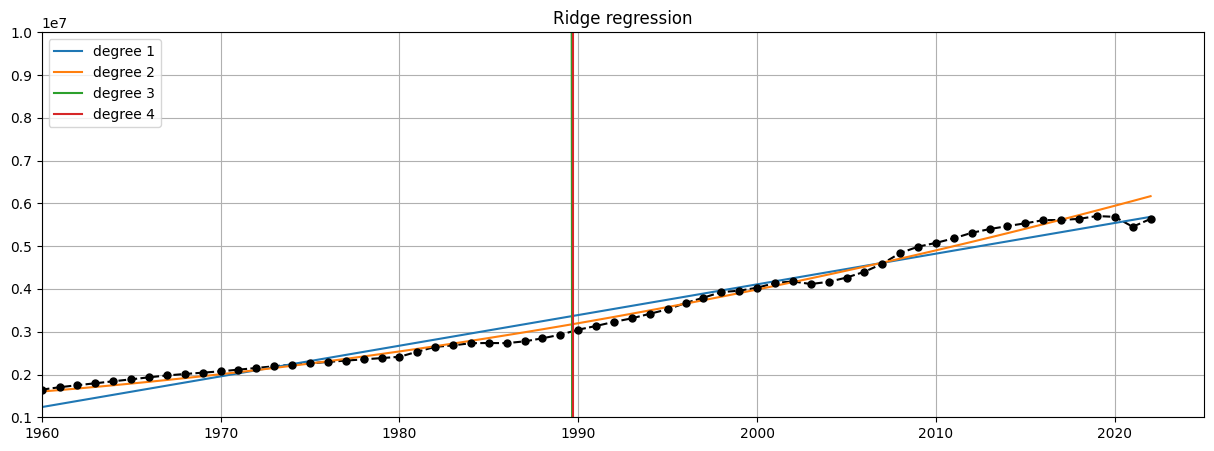

In [ ]:
ridge = lm.RidgeCV()
#x_tr is the test data
fig, ax = plt.subplots(1, 1,  figsize=(15, 5))
ax.plot(x_copy, y, '--k')
for deg, s in zip([1, 2, 3, 4], ['-','-', '-','-']):
    ridge.fit(np.vander(x_flatten[:60], deg + 1), y[:60])
    y_ridge = ridge.predict(np.vander(x_flatten, deg + 1))
    ax.plot(x_copy, y_ridge, s,
            label='degree ' + str(deg))
    ax.legend(loc=2)
    ax.set_xlim(1960, 2025)
    ax.set_ylim(1000000, 10000000)
    # Print the model's coefficients.
    coeff=np.append(ridge.coef_[:-1],ridge.intercept_)
    print(f'Coefficients, degree {deg}:\n\t',' '.join(f'{c:.2f}' for c in coeff ))
    print(coeff)
    print('The MSE of the traning data is : ',mean_squared_error(y_array[:60],y_ridge[:60]))
    print('The MSE of the test data is : ',mean_squared_error(y_array[60:63],y_ridge[60:63]))
ax.plot(x_copy, y, 'ok', ms=5)
ax.set_title("Ridge regression")
ax.grid()

# Various Factors

In [ ]:
data=pd.read_excel("Singapore4.xlsx")
data.columns

Index(['Total Population (Number)', 'Resident Population (Number)',
       'Singapore Citizen Population (Number)',
       'Permanent Resident Population (Number)',
       'Non-Resident Population (Number)'],
      dtype='object')

In [ ]:
data.dtypes

Total Population (Number)                 int64
Resident Population (Number)              int64
Singapore Citizen Population (Number)     int64
Permanent Resident Population (Number)    int64
Non-Resident Population (Number)          int64
dtype: object

In [ ]:
print("In total:",data.shape)
data.head(5)

In total: (33, 5)


,Total Population (Number),Resident Population (Number),Singapore Citizen Population (Number),Permanent Resident Population (Number),Non-Resident Population (Number)
0,5637022,4073239,3553749,519490,1563783
1,5453566,3986842,3498191,488651,1466724
2,5685807,4044210,3523191,521019,1641597
3,5703569,4026209,3500940,525269,1677360
4,5638676,3994283,3471936,522347,1644393


In [ ]:
data.describe()

,Total Population (Number),Resident Population (Number),Singapore Citizen Population (Number),Permanent Resident Population (Number),Non-Resident Population (Number)
count,3.300000e+01,3.300000e+01,3.300000e+01,33.000000,3.300000e+01
mean,4.546775e+06,3.502914e+06,3.121500e+06,381413.909091,1.043861e+06
std,8.853946e+05,4.168570e+05,2.719282e+05,150674.982109,4.738905e+05
min,3.047132e+06,2.735868e+06,2.623736e+06,112132.000000,3.112640e+05
25%,3.927213e+06,3.180018e+06,2.929731e+06,250287.000000,7.290420e+05
50%,4.401365e+06,3.525894e+06,3.107924e+06,417970.000000,8.754710e+05
75%,5.453566e+06,3.870739e+06,3.343030e+06,525269.000000,1.554411e+06
max,5.703569e+06,4.073239e+06,3.553749e+06,541002.000000,1.677360e+06


In [ ]:
cormatrix=data.corr()
cormatrix

,Total Population (Number),Resident Population (Number),Singapore Citizen Population (Number),Permanent Resident Population (Number),Non-Resident Population (Number)
Total Population (Number),1.000000,0.993166,0.986223,0.967820,0.994716
Resident Population (Number),0.993166,1.000000,0.992508,0.975386,0.975936
Singapore Citizen Population (Number),0.986223,0.992508,1.000000,0.941136,0.969555
Permanent Resident Population (Number),0.967820,0.975386,0.941136,1.000000,0.950233
Non-Resident Population (Number),0.994716,0.975936,0.969555,0.950233,1.000000


In [ ]:
cormatrix *=np.tri(*cormatrix.values.shape,k=-1).T
cormatrix

,Total Population (Number),Resident Population (Number),Singapore Citizen Population (Number),Permanent Resident Population (Number),Non-Resident Population (Number)
Total Population (Number),0.0,0.993166,0.986223,0.967820,0.994716
Resident Population (Number),0.0,0.000000,0.992508,0.975386,0.975936
Singapore Citizen Population (Number),0.0,0.000000,0.000000,0.941136,0.969555
Permanent Resident Population (Number),0.0,0.000000,0.000000,0.000000,0.950233
Non-Resident Population (Number),0.0,0.000000,0.000000,0.000000,0.000000


In [ ]:
cormatrix=cormatrix.stack()
cormatrix

Total Population (Number)               Total Population (Number)                 0.000000
                                        Resident Population (Number)              0.993166
                                        Singapore Citizen Population (Number)     0.986223
                                        Permanent Resident Population (Number)    0.967820
                                        Non-Resident Population (Number)          0.994716
Resident Population (Number)            Total Population (Number)                 0.000000
                                        Resident Population (Number)              0.000000
                                        Singapore Citizen Population (Number)     0.992508
                                        Permanent Resident Population (Number)    0.975386
                                        Non-Resident Population (Number)          0.975936
Singapore Citizen Population (Number)   Total Population (Number)                 0.000000

In [ ]:
cormatrix=cormatrix.reindex(cormatrix.abs().sort_values(ascending=False).index).reset_index()
cormatrix

,level_0,level_1,0
0,Total Population (Number),Non-Resident Population (Number),0.994716
1,Total Population (Number),Resident Population (Number),0.993166
2,Resident Population (Number),Singapore Citizen Population (Number),0.992508
3,Total Population (Number),Singapore Citizen Population (Number),0.986223
4,Resident Population (Number),Non-Resident Population (Number),0.975936
5,Resident Population (Number),Permanent Resident Population (Number),0.975386
6,Singapore Citizen Population (Number),Non-Resident Population (Number),0.969555
7,Total Population (Number),Permanent Resident Population (Number),0.967820
8,Permanent Resident Population (Number),Non-Resident Population (Number),0.950233
9,Singapore Citizen Population (Number),Permanent Resident Population (Number),0.941136


In [ ]:
cormatrix.columns=["FirstVariable","SecondVariable","Correlation"]
cormatrix.head(10)

,FirstVariable,SecondVariable,Correlation
0,Total Population (Number),Non-Resident Population (Number),0.994716
1,Total Population (Number),Resident Population (Number),0.993166
2,Resident Population (Number),Singapore Citizen Population (Number),0.992508
3,Total Population (Number),Singapore Citizen Population (Number),0.986223
4,Resident Population (Number),Non-Resident Population (Number),0.975936
5,Resident Population (Number),Permanent Resident Population (Number),0.975386
6,Singapore Citizen Population (Number),Non-Resident Population (Number),0.969555
7,Total Population (Number),Permanent Resident Population (Number),0.967820
8,Permanent Resident Population (Number),Non-Resident Population (Number),0.950233
9,Singapore Citizen Population (Number),Permanent Resident Population (Number),0.941136


<ipython-input-83-4f39802ff8e0>:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask=np.zeros_like(corr_all,dtype=np.bool)


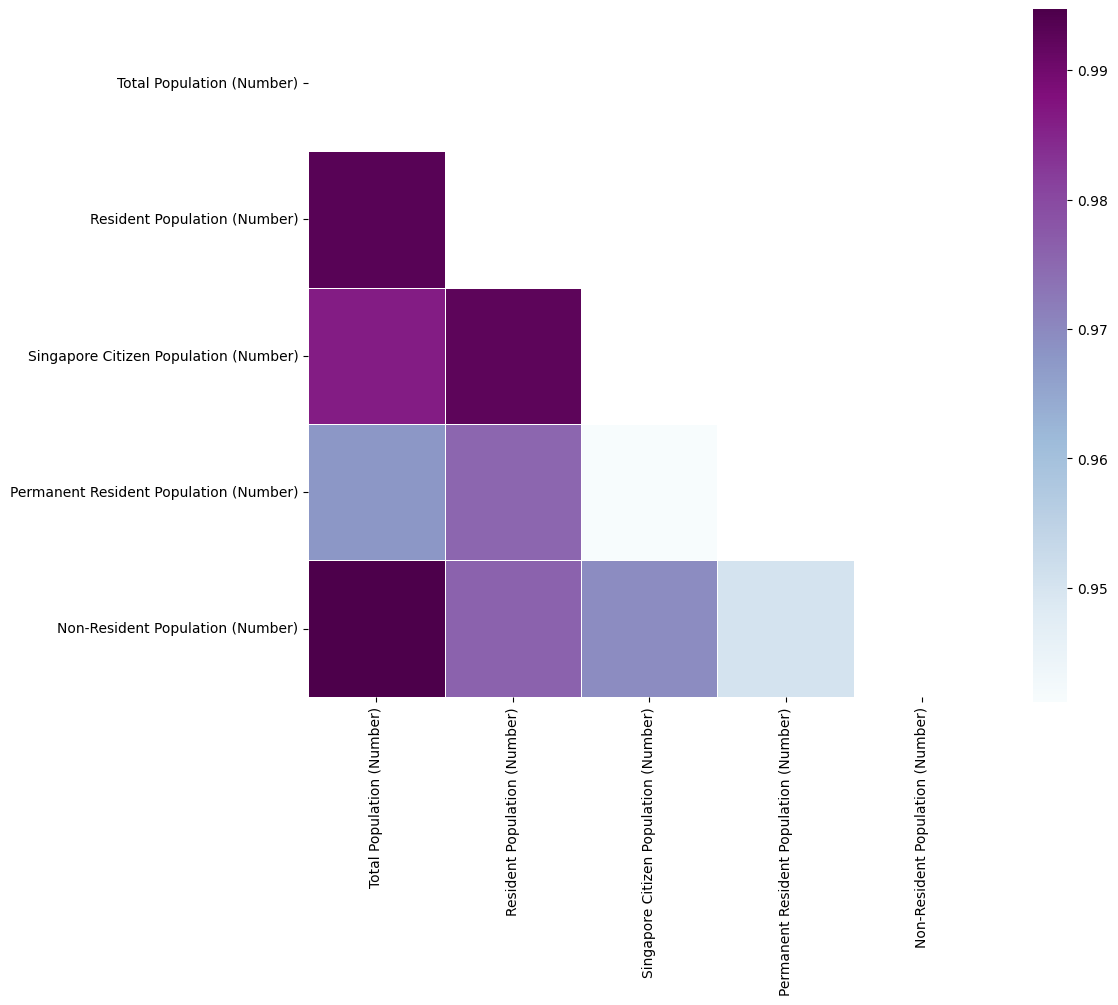

In [ ]:
corr_all=data.corr()

mask=np.zeros_like(corr_all,dtype=np.bool)
mask[np.triu_indices_from(mask)]=True

f,ax=plt.subplots(figsize=(11,9))

sns.heatmap(corr_all,mask=mask,
      square=True,linewidths=.5,ax=ax,cmap="BuPu")
plt.show()

<ipython-input-84-ce0c41241202>:10: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask=np.zeros_like(corr_all,dtype=np.bool)


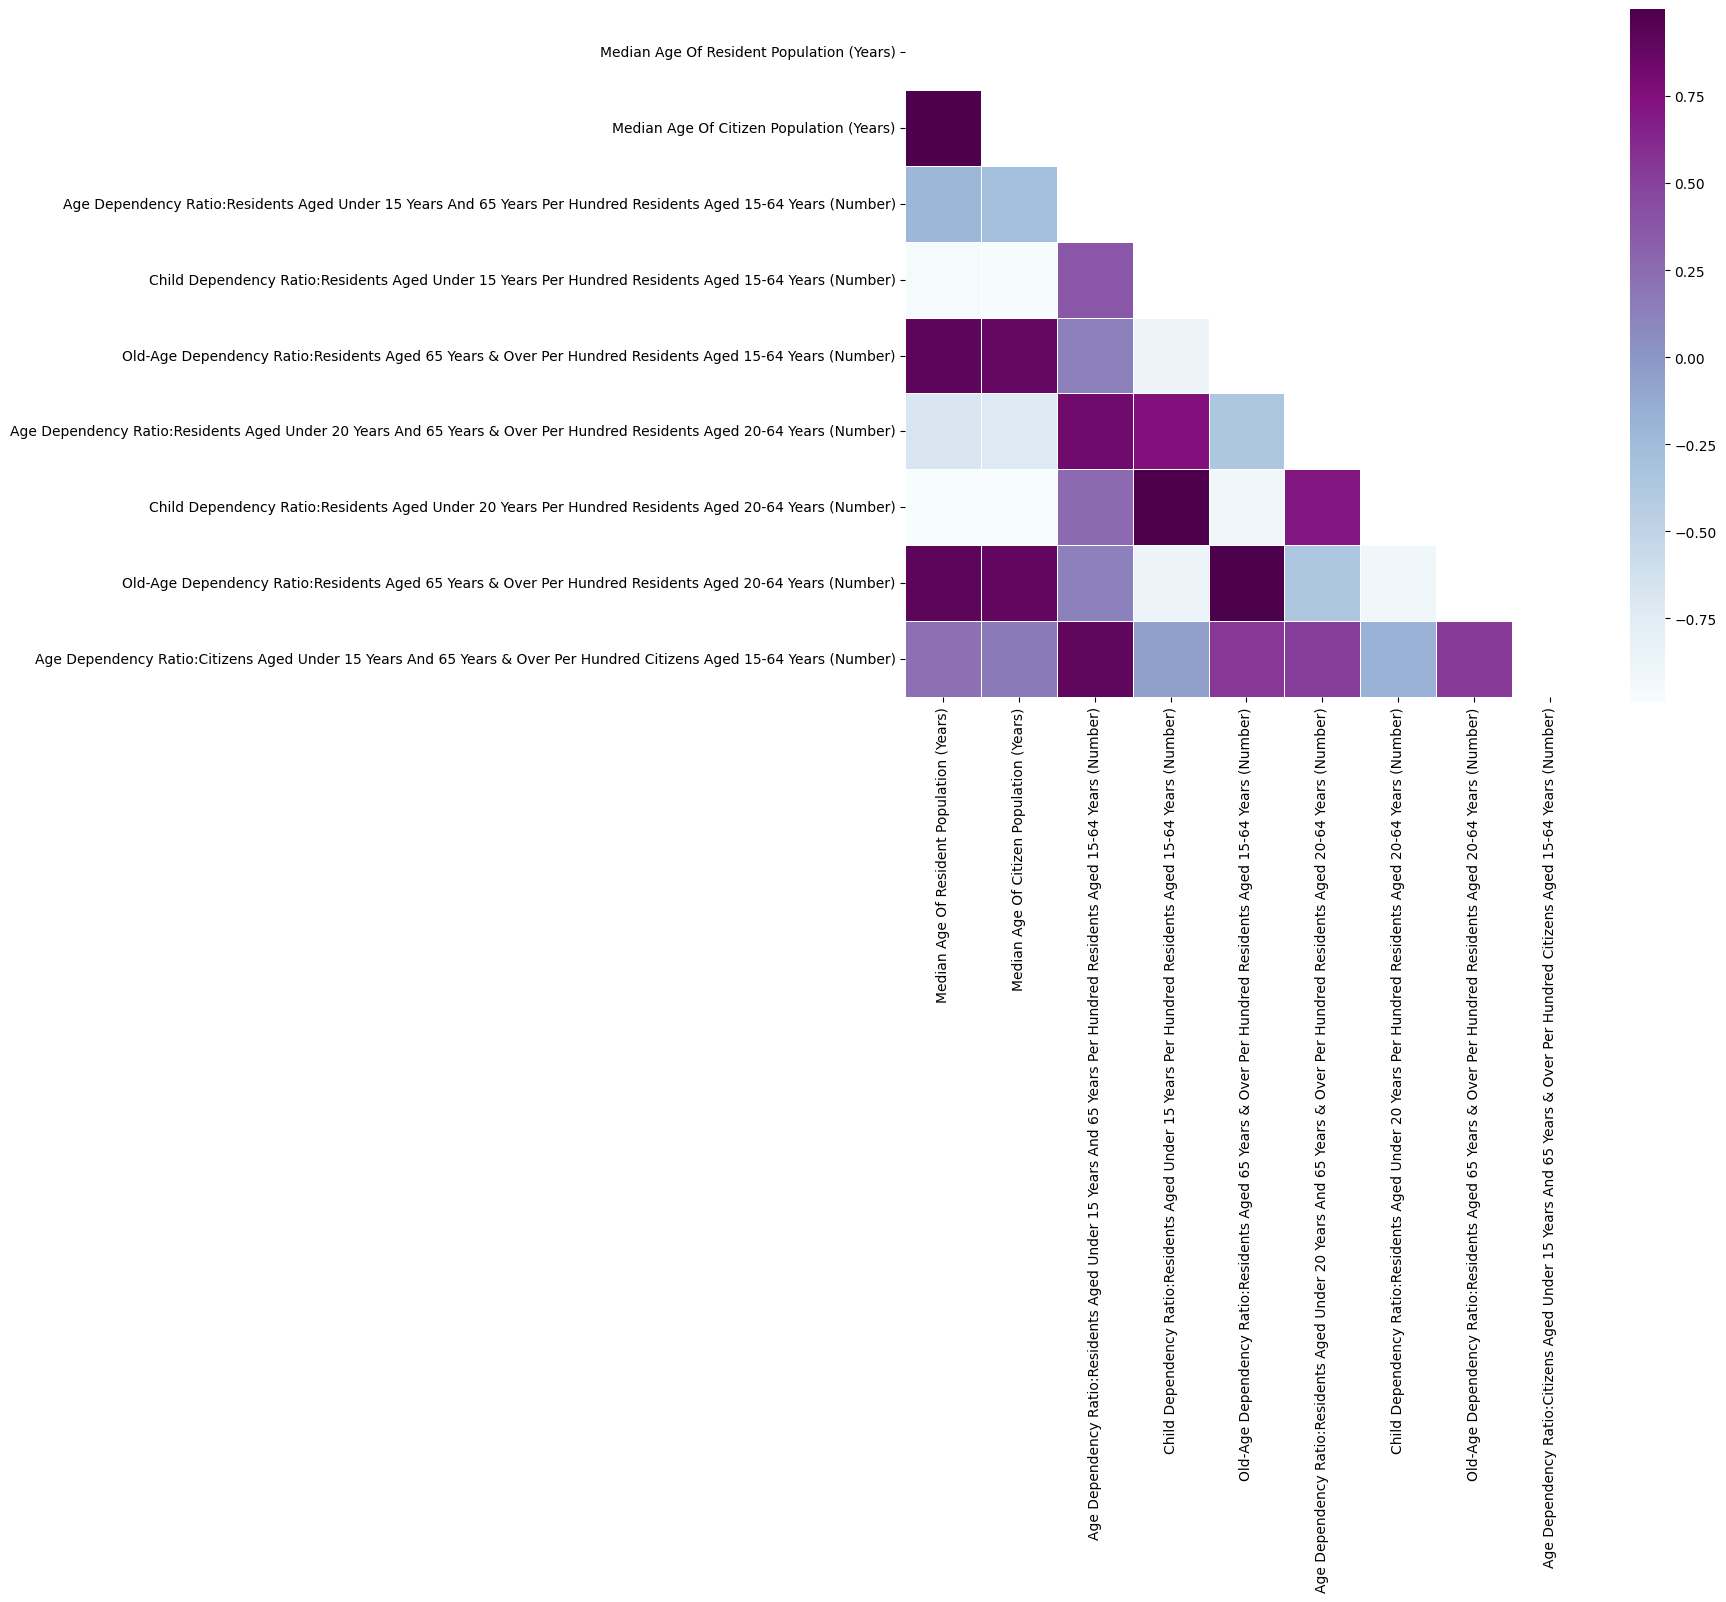

In [ ]:
data=pd.read_excel("Singapore3.xlsx")
data.columns
cormatrix=data.corr()
cormatrix *=np.tri(*cormatrix.values.shape,k=-1).T
cormatrix=cormatrix.stack()
cormatrix=cormatrix.reindex(cormatrix.abs().sort_values(ascending=False).index).reset_index()
cormatrix.columns=["FirstVariable","SecondVariable","Correlation"]
corr_all=data.corr()

mask=np.zeros_like(corr_all,dtype=np.bool)
mask[np.triu_indices_from(mask)]=True

f,ax=plt.subplots(figsize=(11,9))

sns.heatmap(corr_all,mask=mask,
      square=True,linewidths=.5,ax=ax,cmap="BuPu")
plt.show()

## The Population regression of China

In [ ]:
df = pd.read_excel('China.xlsx')
x=df["Year"]
y=df["Populations"]

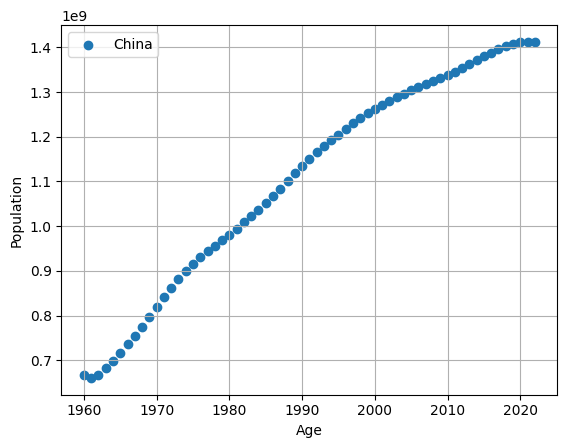

In [ ]:
plt.xlabel("Age")
plt.ylabel("Population")
plt.scatter(x,y,label="China")
plt.legend()
plt.grid()

Model Coefficients [slope, intercept]: [ 1.32390224e+07 -2.52500737e+10]


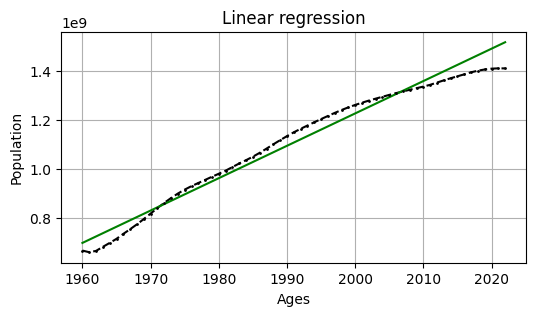

In [ ]:
# We are going to use LinearRegression.
lr = lm.LinearRegression()

# Next, we reshape x so that it satisfies the conditions for the fitting function
x=np.array(x).reshape(-1,1)

# Now we use data from 1960 to 2019 to train the model
lr.fit(x[:60],y[:60])

# Now, we predict points with our trained model.
y_lr = lr.predict(x)

#
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(x, y, '--k')
ax.plot(x, y_lr, 'g')
ax.plot(x, y, 'ok', ms=1)
#ax.set_xlim(0, 1.5)
#ax.set_ylim(-10, 80)
ax.set_title("Linear regression")
plt.xlabel("Ages")
plt.ylabel("Population")
plt.grid()
print('Model Coefficients [slope, intercept]:', np.append(lr.coef_, lr.intercept_))

In [ ]:
print('The difference between the projected population and the actual population in 2020 is : ',int(lr.predict([[2020]])-y[60]),'\n')
print('The difference between the projected population and the actual population in 2021 is : ',int(lr.predict([[2021]])-y[61]),'\n')
print('The difference between the projected population and the actual population in 2022 is : ',int(lr.predict([[2022]])-y[62]),'\n')
print('The projected population of China in 2023 is : ',int(lr.predict([[2023]])),'\n')
print('The projected population of China in 2030 is : ',int(lr.predict([[2030]])),'\n')
print('The projected population of China in 2050 is : ',int(lr.predict([[2050]])),'\n')

The difference between the projected population and the actual population in 2020 is :  81651432 

The difference between the projected population and the actual population in 2021 is :  93630454 

The difference between the projected population and the actual population in 2022 is :  107054476 

The projected population of Singapore in 2023 is :  1532468499 

The projected population of Singapore in 2030 is :  1625141655 

The projected population of Singapore in 2050 is :  1889922103 



In [ ]:
#add one conlumn
x_copy=x.copy()
x=sm.add_constant(x)

#ordinary least squares
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Populations   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.973
Method:                 Least Squares   F-statistic:                     2207.
Date:                Thu, 03 Aug 2023   Prob (F-statistic):           1.32e-49
Time:                        15:02:54   Log-Likelihood:                -1190.2
No. Observations:                  63   AIC:                             2384.
Df Residuals:                      61   BIC:                             2389.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.444e+10   5.44e+08    -44.944      0.0

In [ ]:
cormatrix=df.corr()
cormatrix

,Year,Populations
Year,1.000000,0.986459
Populations,0.986459,1.000000


In [ ]:
# First, we need to change the form of y so that it conforms to the form of the MSE
y_array = np.zeros(63)
for m in range(0,63):
  y_array[m] = y[m]

print('The MSE of the traning data is : ',mean_squared_error(y_array[:60],y_lr[:60]))
print('The MSE of the test data is : ',mean_squared_error(y_array[60:63],y_lr[60:63]))

The MSE of the traning data is :  1210677875537452.2
The MSE of the test data is :  8964759812153248.0


# Use a Polynomial Regression model to make predictions

Coefficients, degree 1:
	 13239022.37 -25250073749.79
[ 1.32390224e+07 -2.52500737e+10]
The MSE of the traning data is :  1210677875537452.2
The MSE of the test data is :  8964759812153248.0
Coefficients, degree 2:
	 -125075.31 510913690.90 -520274438106.17
[-1.25075313e+05  5.10913691e+08 -5.20274438e+11]
The MSE of the traning data is :  85885877444362.19
The MSE of the test data is :  70857187054343.38
Coefficients, degree 3:
	 -942.46 5500021.43 -10679707668.70 6900298052772.78
[-9.42464059e+02  5.50002143e+06 -1.06797077e+10  6.90029805e+12]
The MSE of the traning data is :  71142788062582.47
The MSE of the test data is :  41040797346141.08
Coefficients, degree 4:
	 -0.34 1748.86 -2541925.16 -1916.61 1581986001424.48
[-3.37743321e-01  1.74885844e+03 -2.54192516e+06 -1.91660967e+03
  1.58198600e+12]
The MSE of the traning data is :  71248475118294.1
The MSE of the test data is :  41567666772897.35
Coefficients, degree 5:
	 -0.00 0.62 -802.98 -0.81 -0.00 573201632567.75
[-1.28575531

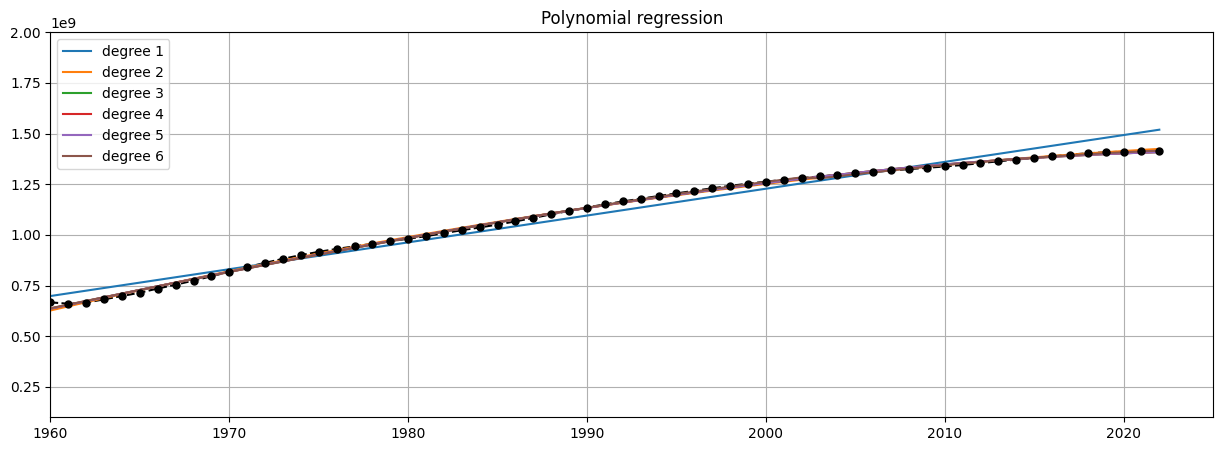

In [ ]:
lrp = lm.LinearRegression()
fig, ax = plt.subplots(1, 1,  figsize=(15, 5))
# Next we will change the two-dimensional array to a one-dimensional array to meet the request
x_flatten = x_copy.flatten()
ax.plot(x_copy, y, '--k')
for deg, s in zip([1, 2, 3, 4, 5, 6], ['-','-', '-','-','-','-']):
    lrp.fit(np.vander(x_flatten[:60], deg + 1), y[:60])
    y_lrp = lrp.predict(np.vander(x_flatten, deg + 1))
    ax.plot(x_copy, y_lrp, s, label='degree ' + str(deg))
    ax.legend(loc=2)
    ax.set_xlim(1960, 2025)
    ax.set_ylim(100000000, 2000000000)
    # Print the model's coefficients.
    coeff=np.append(lrp.coef_[:-1],lrp.intercept_)
    print(f'Coefficients, degree {deg}:\n\t',' '.join(f'{c:.2f}' for c in coeff ))
    print(coeff)
    print('The MSE of the traning data is : ',mean_squared_error(y_array[:60],y_lrp[:60]))
    print('The MSE of the test data is : ',mean_squared_error(y_array[60:63],y_lrp[60:63]))
ax.plot(x_copy, y, 'ok', ms=5)
ax.set_title("Polynomial regression")
ax.grid()

# Use a Ridge regression model to make predictions

Coefficients, degree 1:
	 13231669.40 -25235445016.10
[ 1.32316694e+07 -2.52354450e+10]
The MSE of the traning data is :  1210694090882017.2
The MSE of the test data is :  8921092743436259.0
Coefficients, degree 2:
	 -90605.11 373746246.90 -383827010864.29
[-9.06051094e+04  3.73746247e+08 -3.83827011e+11]
The MSE of the traning data is :  171350219041416.88
The MSE of the test data is :  993090832503063.6
Coefficients, degree 3:
	 593.25 132190.31 -754241.67 -5193378133980.96
[ 5.93250000e+02  1.32190309e+05 -7.54241669e+05 -5.19337813e+12]
The MSE of the traning data is :  1.7127659826734439e+22
The MSE of the test data is :  5.797028735154771e+22
Coefficients, degree 4:
	 120832.00 1653.62 -2333235.68 -1789.13 -1893895499517873152.00
[ 1.20832000e+05  1.65362500e+03 -2.33323568e+06 -1.78912632e+03
 -1.89389550e+18]
The MSE of the traning data is :  4.346384232706149e+33
The MSE of the test data is :  1.4872552458393424e+34


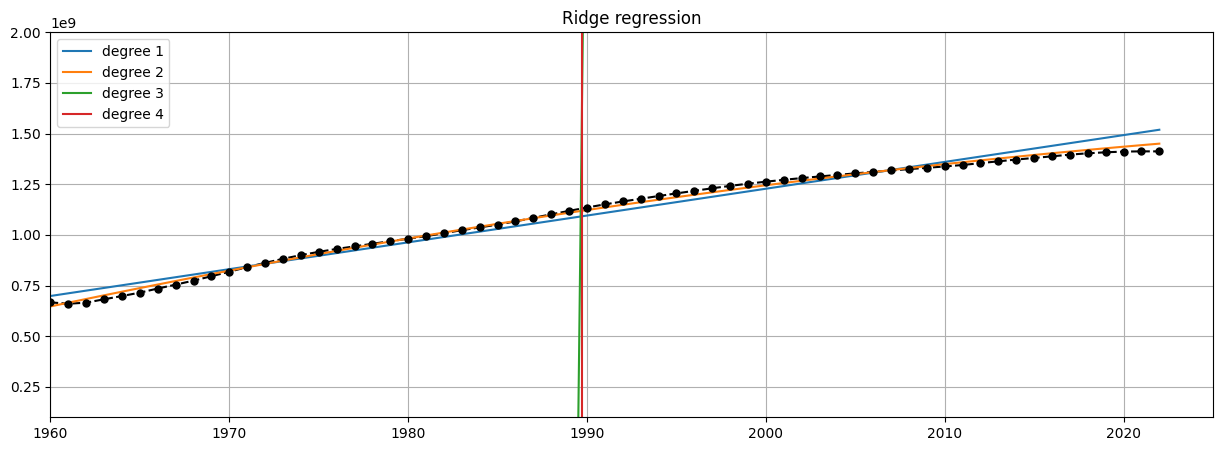

In [ ]:
ridge = lm.RidgeCV()
#x_tr is the test data
fig, ax = plt.subplots(1, 1,  figsize=(15, 5))
ax.plot(x_copy, y, '--k')
for deg, s in zip([1, 2, 3, 4], ['-','-', '-','-']):
    ridge.fit(np.vander(x_flatten[:60], deg + 1), y[:60])
    y_ridge = ridge.predict(np.vander(x_flatten, deg + 1))
    ax.plot(x_copy, y_ridge, s,
            label='degree ' + str(deg))
    ax.legend(loc=2)
    ax.set_xlim(1960, 2025)
    ax.set_ylim(100000000, 2000000000)
    # Print the model's coefficients.
    coeff=np.append(ridge.coef_[:-1],ridge.intercept_)
    print(f'Coefficients, degree {deg}:\n\t',' '.join(f'{c:.2f}' for c in coeff ))
    print(coeff)
    print('The MSE of the traning data is : ',mean_squared_error(y_array[:60],y_ridge[:60]))
    print('The MSE of the test data is : ',mean_squared_error(y_array[60:63],y_ridge[60:63]))
ax.plot(x_copy, y, 'ok', ms=5)
ax.set_title("Ridge regression")
ax.grid()

## Sequence to Sequence

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


# define LSTM model
class LSTMModel(nn.Module):
    def __init__(self, n_features, n_hidden, n_output):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(n_features, n_hidden, num_layers=1, batch_first=True)
        self.fc = nn.Linear(n_hidden, n_output)

    def forward(self, x):
        output, _ = self.lstm(x)
        output = self.fc(output[:, -1, :])
        return output


class Seq2Seq(nn.Module):
    def __init__(self, n_features, hidden_size, output_time_step):
        super(Seq2Seq, self).__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.output_time_step = output_time_step

        self.encoder = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.decoder = nn.LSTM(hidden_size, n_features, batch_first=True)

    def forward(self, input_seq):
        # input_seq's shape：(batch_size, time_steps, n_features)
        batch_size = input_seq.size(0)
        time_steps = self.output_time_step

        # initialize the hiding statement of Encoder
        encoder_hidden = self.init_hidden(batch_size)

        # Encode the input sequence
        encoder_outputs, encoder_hidden = self.encoder(input_seq, encoder_hidden)
        # encoder_outputs.shape = (batch_size, input_timestep, hidden_size)
        # len(encoder_hidden) = 2, 2x (1,batch_size,hidden_size)
        # initialize the hiding statement of Decoder
        decoder_hidden = encoder_hidden

        # Initializes the input to Decoder, represented by an all-zero tensor
        decoder_input = torch.zeros((batch_size, 1, self.hidden_size))
        # (batch_size, 1, hiddensize)
        # Stores the output sequence of the Decoder
        decoder_outputs = torch.zeros((batch_size, time_steps, self.hidden_size))
        # (batch_size, timesteps, hidden_size)
        # Start decoding
        for t in range(time_steps):
            decoder_output, decoder_hidden = self.decoder(decoder_input, decoder_hidden)
            decoder_outputs[:, t:t + 1, :] = decoder_output
            decoder_input = decoder_output

        return decoder_outputs

    def init_hidden(self, batch_size):
        # Initialize the hidden state of LSTM
        return (torch.zeros(1, batch_size, self.hidden_size),
                torch.zeros(1, batch_size, self.hidden_size))


class PopulationExp:
    def __init__(self, filename, data_area, timestep, n_features, predict_from, predict_to, module):
        # Read the Excel file
        self.data = pd.read_excel(filename)

        self.timestep = timestep
        self.n_features = n_features
        self.predict_from = predict_from
        self.n_prediction = predict_to - 2019
        self.row_min, self.row_max, self.col_min, self.col_max = data_area

        self.data_by_years_normalized = None
        self.data_by_years = None
        self.prediction = None

        self.min_value = None
        self.max_value = None
        self.model_name = module

        if self.model_name == "LSTM":
            self.model = LSTMModel(n_features, 30, n_features)
        elif self.model_name == "Seq2Seq":
            self.model = Seq2Seq(self.n_features, self.n_features, self.n_prediction)

        # Define loss functions and optimizers
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.01)
        self.train_loader = None

        self.test_x = None

    def process_data(self):
        data_by_years = self.data.iloc[self.row_min:self.row_max, self.col_min:self.col_max].values
        data_by_years = np.array(data_by_years)
        data_by_years = np.array(data_by_years, dtype='float32')
        # Convert the data to a numpy array and pad the NaN value with 0
        self.data_by_years = np.nan_to_num(data_by_years, nan=0.0)
        # Normalize the data (simply use the maximum and minimum normalization here)
        self.min_value = np.min(self.data_by_years, axis=1, keepdims=True)
        self.max_value = np.max(self.data_by_years, axis=1, keepdims=True)
        self.data_by_years_normalized = (self.data_by_years - self.min_value) / (self.max_value - self.min_value+1)

    def plot_data(self):
        years_list = [year for year in range(1960, 2023)]
        plt.plot(years_list, self.data_by_years[0])
        years_list = [year for year in range(self.predict_from, self.predict_from + self.n_prediction)]
        plt.plot(years_list, self.prediction[0, :, 0])
        plt.show()

    def make_dataset(self):
        x = []
        y = []
        if self.model_name == "LSTM":
            for i in range(self.data_by_years_normalized.shape[1] - self.timestep):
                x.append(self.data_by_years_normalized[:, i:i + self.timestep])
                y.append(self.data_by_years_normalized[:, i + self.timestep])
        elif self.model_name == "Seq2Seq":
            for i in range(self.data_by_years_normalized.shape[1] - self.timestep - self.n_prediction):
                x.append(self.data_by_years_normalized[:, i:i + self.timestep])
                y.append(self.data_by_years_normalized[:, i + self.timestep:i + self.timestep + self.n_prediction])

        x = np.array(x, dtype="float32")
        y = np.array(y, dtype="float32")

        # Convert the data to PyTorch's Tensor type
        x = torch.tensor(x, dtype=torch.float32).permute(0, 2, 1)
        y = torch.tensor(y, dtype=torch.float32).permute(0, 2, 1)  # .unsqueeze(1)

        # train_x = x[:-1 * (2023 - self.predict_from)]
        # train_y = y[:-1 * (2023 - self.predict_from)]
        train_x = x
        train_y = y

        self.test_x = self.data_by_years_normalized[:,self.data_by_years_normalized.shape[1] - (2023 - self.predict_from + self.timestep):self.data_by_years_normalized.shape[1] - (2023 - self.predict_from)]
        # establish DataLoader
        train_dataset = TensorDataset(train_x, train_y)
        self.train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    def train(self):
        # Train an LSTM model
        loss = None
        num_epochs = 1000
        for epoch in range(num_epochs):
            for batch_X, batch_y in self.train_loader:
                self.optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = self.criterion(outputs, batch_y)
                loss.backward()
                self.optimizer.step()

            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

    def test(self):
        """
        # 在测试集上进行预测

        # 单点测试
        print("单点测试")
        self.model.eval()
        with torch.no_grad():
            for batch_X, batch_y in self.test_loader:
                y_pred = self.model(batch_X)
                # 反归一化预测结果
                y_pred = y_pred * (self.max_value[0] - self.min_value[0]) + self.min_value[0]
                y_real = batch_y * (self.max_value[0] - self.min_value[0]) + self.min_value[0]
                # 可以进一步对预测结果进行评估，比如计算均方误差 (MSE) 或 R^2 等指标

                print("预测值:", y_pred[:, 0])
                print("真实值:", y_real[:, 0])

        # 连续测试
        print("连续测试")
        self.model.eval()
        with torch.no_grad():
            output = []
            input = self.test_dataset[0][0].unsqueeze(0)
            for i in range(self.n_prediction):
                y_pred = self.model(input)
                output.append(y_pred[0][0])
                input = torch.roll(input, -1, dims=1)
                input[0, -1] = y_pred

            output = output * (self.max_value[0] - self.min_value[0]) + self.min_value[0]
            print("预测值:", output)
            print("真实值:", y_real[:, 0])

        self.prediction = output
        """
        print("连续测试")
        self.model.eval()
        with torch.no_grad():
            y_pred = self.model(torch.tensor(self.test_x).unsqueeze(0).permute(0, 2, 1))
            output = y_pred * (self.max_value[0] - self.min_value[0]) + self.min_value[0]
        print("预测值:", output)

        self.prediction = output

    def main(self):
        self.process_data()
        self.make_dataset()
        self.train()
        self.test()
        self.plot_data()


if __name__ == "__main__":
    exp = PopulationExp("xxx.xls", data_area=(43, 44, 4, 67), timestep=20, n_features=1, predict_from=2020,
                        predict_to=2050, module="Seq2Seq")
    exp.main()
